# 06 · feature engineering v2 — going all-in on peer-relative

**Where we stand (nb05, leak-proofed):** walk-forward accuracy 0.410 / macro-F1 0.396 with 20
features. The ablation there produced the design insight for this notebook: **generic technical
indicators alone scored 0.366 — worse than the 3 crude features (0.389)** — while every point of
lift came from the *peer-relative* features (skip-momentum, category-beta, relative strength).

**Why that makes sense:** the label is a cross-sectional question — "will this fund beat *its
peers* over the next 5 days?" A feature that describes the fund in isolation (RSI = 61) says
little about where the fund stands inside its pack, and its scale means different things in
different categories. Features expressed *relative to the category* line up with the label's
geometry and are comparable across asset classes (which matters: nb02 showed bonds and sector
equity are nearly different problems).

**What v2 adds** (16 new features, all trailing, every one documented below): cross-sectional
ranks, beta-adjusted (residual) momentum, "benchmark-hugger" measures of deviation propensity,
vol-normalized signals, and category-regime context.

**Evaluation discipline** (carried over from the leakage-proofing pass):
- same purged harness as nb04/05: trading-day purge at every split, label-window assertions
- **2026 is a touch-once holdout** — features and model capacity are selected on the 2021–2025
  dev folds and the single-split ablation only; 2026 is scored exactly once, at the very end,
  with the final configuration, and we report whatever it says
- forward-corr audit, truncation spot-check, shuffled-label test and planted-leak canary all
  re-run against the new feature set

This notebook is self-contained (raw prices + config.yaml only) and leaves 03/04/05 untouched.

In [2]:
import yaml, pathlib
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from xgboost import XGBClassifier
sns.set_theme(style='whitegrid')

ROOT = pathlib.Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
cfg = yaml.safe_load(open(ROOT / 'config.yaml', encoding='utf-8'))
RAW, PROC = ROOT / cfg['paths']['raw'], ROOT / cfg['paths']['processed']
prices   = pd.read_parquet(RAW / 'prices.parquet'); prices.index.name='date'; prices.columns.name='ticker'
metadata = pd.read_parquet(RAW / 'metadata.parquet')
H, MIN = cfg['labels']['horizon'], cfg['labels']['min_group']
fcfg, v2cfg = cfg['features'], cfg['features_v2']

# clean like 04/05: drop leveraged + bad ticks, KEEP delisted (survivorship-safe). drop tiny cats + Uncategorized.
badf = metadata['is_leveraged'].fillna(False) | metadata['bad_ticks'].fillna(False)
prices = prices.drop(columns=[t for t in metadata.index[badf] if t in prices.columns])
cat = metadata['category'].reindex(prices.columns)
sizes = cat.value_counts(); keep_cats = sizes[(sizes >= MIN) & (sizes.index != 'Uncategorized')].index
keep = cat[cat.isin(keep_cats)].index; prices = prices[keep]; cat = cat[keep]
grp = metadata['category_group'].reindex(prices.columns)
print('panel:', prices.shape, '|', len(keep_cats), 'categories (delisted kept)')

panel: (2512, 1628) | 35 categories (delisted kept)


## label — tercile of excess forward-5d return  (identical to nb04/05)

fund forward-5d return minus category **median** forward return, ranked into terciles within each
(date, category). the forward window is the *target*, allowed to see the future; everything in X
below is trailing. tail assertion + the trading-day `purge_cutoff` helper come along.

In [3]:
fwd = prices.shift(-H) / prices - 1.0
excess = fwd - fwd.T.groupby(cat).transform('median').T
ex = excess.stack().rename('excess').reset_index(); ex['cat'] = ex['ticker'].map(cat)
g = ex.groupby(['date', 'cat'])['excess']
pct = g.rank(pct=True); size = g.transform('size')
lab = np.select([pct <= 1/3, pct <= 2/3], [0, 1], default=2).astype(float); lab[size < MIN] = np.nan
ex['label'] = lab; label = ex.set_index(['date', 'ticker'])['label']
assert label.index.get_level_values('date').max() <= prices.index[-(H+1)], 'incomplete forward window leaked through'

def purge_cutoff(trading_index, test_start, h):
    """Last train date whose forward-h label window ends on/before test_start.
    trading_index: the price panel's DatetimeIndex (actual trading days)."""
    pos = trading_index.searchsorted(pd.Timestamp(test_start))
    return trading_index[max(pos - h, 0)]

print('label rows:', int(label.notna().sum()), '| balance', label.value_counts(normalize=True).round(3).to_dict())

label rows: 3447076 | balance {2.0: 0.341, 1.0: 0.333, 0.0: 0.326}


## the feature catalogue — every feature and why it should work

### base set carried over from nb05 (20) — "C"

- **trailing returns** `ret_1d, ret_5d, ret_10d, ret_20d` — raw momentum/reversal at horizons
  bracketing the label's week. Weak alone (nb03: best linear separation 0.04 std) but they're the
  raw material the tree combines with the relative features.
- **volatility** `vol_20d` — annualized 20d realized vol. EDA: P(Outperform) rises monotonically
  with vol — volatile funds *leave the pack* more often, in both directions, and the tercile
  label rewards deviation.
- **trend distance** `px_to_sma_10/20/50`, `px_to_ema_10/20/50` — price vs its own moving
  averages (scale-free trend state). Highly mutually redundant (|corr| ≈ 0.98 within pairs);
  kept because trees ignore what they don't need.
- **oscillators** `rsi_14, macd, macd_signal, macd_hist, bb_pctb, bb_bandwidth` — overbought /
  oversold and squeeze/expansion state; EDA found mild mean-reversion in the rsi and %b deciles.
- **friend-derived, recomputed in-house** — `ret_20d_skip5`: 20d momentum measured 5 days ago
  (skips the week that mean-reverts); `beta_60d`: 60d beta to the fund's *own category*
  composite — structural aggressiveness inside the peer group; `rel_str_5d`: trailing 5d return
  minus category mean — last week's version of exactly what the label measures next week.

### new — position within the pack (4)

The label is a *rank*, so give the model ranks. A +2% week means nothing until you know whether
the pack did +4% or −1%, and ranks erase asset-class scale (a "big move" in munis is tiny in
semis). All ranks are pct-ranks within (date, category), trailing data only.

- **`cs_rank_ret_1d`** — where *yesterday's* return sits among peers (0 = worst, 1 = best). At
  1–5 day horizons the strongest cross-sectional equity effect is short-term **reversal**
  (liquidity provision: yesterday's extreme losers bounce, extreme winners fade). The V-shape the
  EDA found in the momentum deciles lives exactly here.
- **`cs_rank_ret_5d`** — last week's rank: the natural autoregressive feature for a
  next-week's-rank target.
- **`cs_rank_skip_mom`** — rank of `ret_20d_skip5`. Separates the *reversal week* from the
  *momentum month* (the classic skip construction scaled down): a monthly leader that just had a
  losing week is in a different state than a monthly leader still running.
- **`cs_rank_vol_20d`** — vol rank within category: the EDA's vol effect made cross-class
  comparable. It's *relative* volatility that predicts who escapes the pack.

### new — alpha vs beta (2)

- **`resid_ret_5d` / `resid_ret_20d`** — fund return minus `beta_60d ×` category return. Raw
  relative strength confounds *selection* (fund-specific alpha) with *beta* (a 1.3-beta fund
  beats the category average mechanically in any up week — and gives it back in down weeks).
  Residualizing isolates the fund-specific component, which persists differently than the beta
  artifact.

### new — deviation propensity: who even *can* leave the pack (5)

The tercile label rewards deviation from the median *in either direction*. These measure a
fund's structural tendency to deviate at all — direction-free, so they can't be confused with
market timing, and arguably the purest signal for a 3-class peer-relative target.

- **`corr_cat_60d`** — rolling 60d correlation of daily returns with the category composite: the
  **benchmark-hugger score**. An index-like fund tracking its category at ρ≈0.99 lands in
  Neutral week after week; a concentrated/thematic fund at ρ≈0.7 keeps escaping.
- **`idio_vol_20d`** — `vol_20d × √(1−ρ²)`: the volatility *not explained by* the category —
  the escape velocity itself, purer than raw vol.
- **`rel_vol_20d`** — vol vs the category's average vol (level companion to the rank version).
- **`tstat_rel_5d`** — last week's excess return in units of the fund's own daily vol (×√5):
  "how unusual was this week *for this fund*". A 40 bp beat is enormous for a treasury fund and
  noise for biotech; the t-stat makes the signal one currency across classes.
- **`beat_rate_20d`** — share of the last 20 days beating the category mean. Separates
  *persistent* small edges (fees, structural tilts — the kind likely to persist next week) from
  one lumpy day (the kind that mean-reverts).

### new — context the fund sits in (5)

- **`px_to_52w_high`** — distance below the 52-week high. The 52-week-high effect: investors
  anchor and under-react near highs (continuation), while funds far below their high trade like
  fallen knives with fat two-sided tails.
- **`ret_60d_skip5`** — quarterly momentum with the reversal week skipped: medium-horizon trend
  between `ret_20d_skip5` and the 52w anchor.
- **`cat_disp_5d`** — cross-sectional std of trailing 5d returns inside the category *that day*:
  the **regime dial**. High dispersion → funds are separating → non-Neutral labels get likely for
  everyone (nb02: neutral share swings ~45% ↔ ~60% between volatile and calm years). A tree can
  gate every other feature on this.
- **`cat_ret_5d`** — the pack's own trailing week: direction context for the beta/residual
  features.
- **`cat_n`** — number of live peers that day. With 5 peers a tercile boundary is one fund wide
  and the label is noisy; with 100 it's granular. Lets the model discount thin categories.

### deliberately (re)included and deliberately excluded

Cross-sectional ranks were excluded in nb05 on the argument that they "share the ranking
mechanism with the label". That is a construction *similarity*, not leakage — a rank of
**trailing** returns uses only data ≤ t and would be available in production. The audits below
(truncation, forward-corr, shuffled-label, canary) test the actual failure mode directly.

Excluded, with reasons: **fund flows** (the strongest predictor in the fund literature — not
available on yfinance), **AUM / expense ratio** (no point-in-time history, only
as-of-download-date values → lookahead), anything built from the `exclude_delisted` processed
datasets (survivorship-biased — see nb02/03 warnings).

In [4]:
def rsi(px, p=14):
    d_ = px.diff(); up = d_.clip(lower=0); dn = -d_.clip(upper=0)
    ag = up.ewm(alpha=1/p, adjust=False, min_periods=p).mean(); al = dn.ewm(alpha=1/p, adjust=False, min_periods=p).mean()
    return 100 - 100/(1 + ag/al)

def build_features(prices, cat, fcfg, v2cfg):
    """All 36 features as wide (date x ticker) frames. Every input strictly trailing (data <= t).
    Single function on purpose: the truncation check below re-runs it on a truncated panel."""
    rets = prices.pct_change(fill_method=None)
    catmean_ret = rets.T.groupby(cat).transform('mean').T          # trailing daily category composite
    f = {}
    # --- base 17 technical (identical construction to nb05) ---
    f['ret_1d'] = rets
    for w in fcfg['return_windows']: f[f'ret_{w}d'] = prices.pct_change(w, fill_method=None)
    f['vol_20d'] = np.log(prices).diff().rolling(fcfg['vol_window']).std() * np.sqrt(252)
    for w in fcfg['sma_windows']: f[f'px_to_sma_{w}'] = prices / prices.rolling(w).mean() - 1
    for w in fcfg['ema_windows']: f[f'px_to_ema_{w}'] = prices / prices.ewm(span=w, adjust=False).mean() - 1
    f['rsi_14'] = rsi(prices, fcfg['rsi_period'])
    m = fcfg['macd']; ef, es = prices.ewm(span=m['fast'], adjust=False).mean(), prices.ewm(span=m['slow'], adjust=False).mean()
    line = ef - es; sig = line.ewm(span=m['signal'], adjust=False).mean()
    f['macd'] = line/prices; f['macd_signal'] = sig/prices; f['macd_hist'] = (line-sig)/prices
    b = fcfg['bollinger']; mid = prices.rolling(b['window']).mean(); sd = prices.rolling(b['window']).std()
    f['bb_pctb'] = (prices - (mid - b['num_std']*sd)) / (2*b['num_std']*sd); f['bb_bandwidth'] = (2*b['num_std']*sd)/mid
    # --- friend-derived 3 (identical construction to nb05) ---
    W = v2cfg['corr_window']
    f['ret_20d_skip5'] = prices.shift(5) / prices.shift(25) - 1
    covm = (rets*catmean_ret).rolling(W).mean() - rets.rolling(W).mean()*catmean_ret.rolling(W).mean()
    f['beta_60d'] = covm / catmean_ret.rolling(W).var().clip(lower=1e-8)
    cat5 = f['ret_5d'].T.groupby(cat).transform('mean').T
    f['rel_str_5d'] = f['ret_5d'] - cat5
    # --- v2: position within the pack ---
    def cs_rank(w): return w.T.groupby(cat).rank(pct=True).T
    f['cs_rank_ret_1d'] = cs_rank(rets)
    f['cs_rank_ret_5d'] = cs_rank(f['ret_5d'])
    f['cs_rank_skip_mom'] = cs_rank(f['ret_20d_skip5'])
    f['cs_rank_vol_20d'] = cs_rank(f['vol_20d'])
    # --- v2: alpha vs beta ---
    cat20 = f['ret_20d'].T.groupby(cat).transform('mean').T
    f['resid_ret_5d'] = f['ret_5d'] - f['beta_60d'] * cat5
    f['resid_ret_20d'] = f['ret_20d'] - f['beta_60d'] * cat20
    # --- v2: deviation propensity ---
    corr = rets.rolling(W).corr(catmean_ret)
    f['corr_cat_60d'] = corr
    f['idio_vol_20d'] = f['vol_20d'] * np.sqrt(1 - corr.clip(-1, 1)**2)
    f['rel_vol_20d'] = f['vol_20d'] / f['vol_20d'].T.groupby(cat).transform('mean').T
    f['tstat_rel_5d'] = f['rel_str_5d'] / (f['vol_20d']/np.sqrt(252)*np.sqrt(5)).clip(lower=1e-6)
    wins = (rets > catmean_ret).astype(float).where(rets.notna() & catmean_ret.notna())
    f['beat_rate_20d'] = wins.rolling(v2cfg['beat_window'], min_periods=v2cfg['beat_window']).mean()
    # --- v2: context ---
    f['px_to_52w_high'] = prices / prices.rolling(v2cfg['high_window'], min_periods=60).max() - 1
    sm = v2cfg['skip_mom']
    f['ret_60d_skip5'] = prices.shift(sm['skip']) / prices.shift(sm['skip'] + sm['window']) - 1
    f['cat_disp_5d'] = f['ret_5d'].T.groupby(cat).transform('std').T
    f['cat_ret_5d'] = cat5
    f['cat_n'] = f['ret_5d'].notna().T.groupby(cat).transform('sum').T.where(prices.notna())
    return f

feat = build_features(prices, cat, fcfg, v2cfg)

TECH   = ['ret_1d','ret_5d','ret_10d','ret_20d','vol_20d','px_to_sma_10','px_to_sma_20','px_to_sma_50',
          'px_to_ema_10','px_to_ema_20','px_to_ema_50','rsi_14','macd','macd_signal','macd_hist','bb_pctb','bb_bandwidth']
FRIEND = ['ret_20d_skip5','beta_60d','rel_str_5d']
POS    = ['cs_rank_ret_1d','cs_rank_ret_5d','cs_rank_skip_mom','cs_rank_vol_20d']
ALPHA  = ['resid_ret_5d','resid_ret_20d','corr_cat_60d','idio_vol_20d','rel_vol_20d','tstat_rel_5d','beat_rate_20d']
CTX    = ['px_to_52w_high','ret_60d_skip5','cat_disp_5d','cat_ret_5d','cat_n']
C20 = TECH + FRIEND
D36 = C20 + POS + ALPHA + CTX
assert list(feat.keys()) == D36, 'feature build/list drifted apart'

X = pd.concat({k: feat[k].stack() for k in D36}, axis=1).astype('float32')
X.index.names = ['date', 'ticker']
print('feature matrix:', X.shape, '| base C:', len(C20), '+ new:', len(POS + ALPHA + CTX), '=', len(D36))

feature matrix: (4086476, 36) | base C: 20 + new: 16 = 36


## truncation spot-check — new features are leak-free by construction

same gold-standard check as nb03, adapted for cross-sectional features (they need the whole
*panel* truncated, not one ticker): rebuild all 16 new features from `prices.loc[:t]` at 3 random
dates and require the full cross-section at t to match the full-panel build. any feature that
secretly used data past t would differ.

In [5]:
rng = np.random.default_rng(0)
NEW = POS + ALPHA + CTX
cand = X.index.get_level_values('date').unique().sort_values()
cand = cand[cand >= pd.Timestamp('2021-01-01')]
check_dates = pd.to_datetime(sorted(rng.choice(cand.values, size=3, replace=False)))
bad = []
for t in check_dates:
    ft = build_features(prices.loc[:t], cat, fcfg, v2cfg)
    for name in NEW:
        full_row, trunc_row = feat[name].loc[t], ft[name].loc[t]
        both = full_row.notna() & trunc_row.notna()
        same_vals = np.allclose(full_row[both], trunc_row[both], rtol=1e-5, atol=1e-8)
        same_nans = (full_row.isna() == trunc_row.isna()).all()
        if not (same_vals and same_nans):
            bad.append((t.date(), name))
print(f'truncation check: {3*len(NEW) - len(bad)}/{3*len(NEW)} (date, feature) cross-sections reproduce from data <= t')
assert not bad, f'lookahead detected in: {bad}'
print('PASS: every new feature is computable from the truncated panel alone.')

truncation check: 48/48 (date, feature) cross-sections reproduce from data <= t
PASS: every new feature is computable from the truncated panel alone.


## leakage audit — forward correlation

every feature's |corr| with the *forward* excess return. trailing features should all be small; a
spike would mean something is peeking ahead. (nb05's max was 0.037, on rel_str_5d.)

In [6]:
aud = X.join(excess.stack().rename('excess'), how='inner').dropna(subset=['excess'])
leak = aud[D36].corrwith(aud['excess']).abs().sort_values(ascending=False)
print('|corr(feature, forward excess)|:')
print(leak.round(3).to_string())
print()
print('MAX:', round(leak.max(), 3), '->', 'OK, trailing-sized' if leak.max() < 0.15 else 'INVESTIGATE')
del aud

|corr(feature, forward excess)|:
rel_str_5d          0.037
cs_rank_ret_1d      0.026
resid_ret_5d        0.021
cs_rank_ret_5d      0.021
ret_5d              0.019
ret_1d              0.018
px_to_sma_10        0.018
px_to_ema_10        0.016
corr_cat_60d        0.015
bb_bandwidth        0.013
beta_60d            0.013
vol_20d             0.011
resid_ret_20d       0.010
cs_rank_vol_20d     0.010
px_to_ema_20        0.009
ret_20d_skip5       0.009
idio_vol_20d        0.008
tstat_rel_5d        0.007
cs_rank_skip_mom    0.007
px_to_sma_20        0.006
px_to_ema_50        0.005
rsi_14              0.004
cat_disp_5d         0.004
rel_vol_20d         0.004
cat_ret_5d          0.003
ret_10d             0.003
cat_n               0.003
macd_hist           0.003
px_to_52w_high      0.002
px_to_sma_50        0.002
macd                0.002
beat_rate_20d       0.002
ret_20d             0.001
ret_60d_skip5       0.001
macd_signal         0.001
bb_pctb             0.001

MAX: 0.037 -> OK, trailing-siz

In [7]:
data = X.join(label).dropna()
data['label'] = data['label'].astype(int)
data.to_parquet(PROC / 'dataset_v2.parquet')
d = data.reset_index()
del feat, X
print('modeling rows:', data.shape, '->', PROC / 'dataset_v2.parquet')
print('(slightly fewer rows than nb05: the 60-65d warm-ups of corr/skip-60/52w-high trim the early panel)')
print('label balance:', d['label'].value_counts(normalize=True).round(3).to_dict())

modeling rows: (3333385, 37) -> C:\Users\user\Desktop\CS\overp\outperforming\data\processed\dataset_v2.parquet
(slightly fewer rows than nb05: the 60-65d warm-ups of corr/skip-60/52w-high trim the early panel)
label balance: {2: 0.341, 1: 0.333, 0: 0.325}


In [8]:
def _check_cuda():
    try:
        import xgboost as xgb
        dm = xgb.DMatrix([[1, 2], [3, 4]], label=[0, 1])
        xgb.train({'tree_method': 'hist', 'device': 'cuda', 'objective': 'binary:logistic'},
                  dm, num_boost_round=1, verbose_eval=False)
        return True
    except Exception:
        return False

USE_CUDA = _check_cuda()
print('CUDA available for XGBoost:', USE_CUDA)

def make_model(overrides=None):
    params = dict(objective='multi:softprob', num_class=3,
                  n_estimators=250, max_depth=4, learning_rate=0.1,
                  subsample=0.8, colsample_bytree=0.8, tree_method='hist',
                  n_jobs=-1, eval_metric='mlogloss', random_state=0)
    if overrides:
        params.update(overrides)
    if USE_CUDA:
        params['device'] = 'cuda'; params.pop('n_jobs', None)
    return XGBClassifier(**params)

def fit_eval(train, test, cols, overrides=None):
    mdl = make_model(overrides).fit(train[cols], train['label'])
    p = mdl.predict(test[cols])
    return mdl, p, accuracy_score(test['label'], p), f1_score(test['label'], p, average='macro')

CUDA available for XGBoost: True


## 1) grouped ablation — what does each new group buy?  (purged dev split, test 2024+)

same single purged split as nb04/05 (nominal 2023-12-31). **development view only** — the
walk-forward below is the honest number. the base-C row may differ from nb05's 0.411 in the 3rd
decimal because rows here are aligned to the v2 warm-ups (same-rows comparison is the fair one).
the dev-split winner gets carried into the walk-forward.

In [9]:
split = pd.Timestamp(cfg['split']['date'])
te_s = d[d['date'] > split]
cut = purge_cutoff(prices.index, te_s['date'].min(), H)
tr_s = d[d['date'] <= cut]
sets = [('C base (20)', C20), ('C + position (24)', C20 + POS), ('C + alpha/propensity (27)', C20 + ALPHA),
        ('C + context (25)', C20 + CTX), ('D full (36)', D36)]
rows = []
for name, cols in sets:
    _, p, acc, mf1 = fit_eval(tr_s, te_s, cols)
    rows.append({'feature_set': name, 'n_feat': len(cols), 'accuracy': round(acc, 3), 'macro_F1': round(mf1, 3)})
abl = pd.DataFrame(rows); abl['vs_C'] = (abl['accuracy'] - abl.loc[0, 'accuracy']).round(3)
print(f'purge cutoff {cut.date()} | train {len(tr_s):,} rows, test {len(te_s):,} rows')
print(abl.to_string(index=False))
bi = int(abl['accuracy'].idxmax())
best_name, best_cols = sets[bi]
print(f'\nselected for walk-forward (dev-split winner): {best_name}')

C:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\core.py:751: UserWarning: [12:36:51] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


purge cutoff 2023-12-22 | train 2,472,304 rows, test 855,323 rows
              feature_set  n_feat  accuracy  macro_F1  vs_C
              C base (20)      20     0.411     0.395 0.000
        C + position (24)      24     0.434     0.424 0.023
C + alpha/propensity (27)      27     0.432     0.421 0.021
         C + context (25)      25     0.422     0.405 0.011
              D full (36)      36     0.442     0.433 0.031

selected for walk-forward (dev-split winner): D full (36)


In [10]:
# capacity probe (dev split only): 36 features may want deeper interactions than depth-4 allows
_, p, probe_acc, probe_mf1 = fit_eval(tr_s, te_s, best_cols, overrides={'max_depth': 6, 'n_estimators': 400})
std_acc = abl.loc[bi, 'accuracy']
print(f'capacity probe (depth 6, 400 trees) on {best_name}: acc {probe_acc:.3f} mf1 {probe_mf1:.3f}  vs standard {std_acc:.3f}')
run_tuned = probe_acc >= std_acc + 0.003
print('=> will', 'ALSO walk-forward the tuned config' if run_tuned else 'keep the nb05-standard config (probe gain too small)')

capacity probe (depth 6, 400 trees) on D full (36): acc 0.443 mf1 0.435  vs standard 0.442
=> will keep the nb05-standard config (probe gain too small)


## 2) walk-forward, purged — dev years 2021–2025

identical harness to nb05: expanding window, trading-day purge, per-fold label-window assertion,
non-overlapping (every 5th trading day) re-score. **2026 is NOT in this loop** — it's the
touch-once holdout, scored once at the very end. reference: nb05's set C on these same five
folds: dev-mean accuracy 0.409 / macro-F1 0.393.

In [11]:
REF05 = {2021: (0.411, 0.400), 2022: (0.408, 0.400), 2023: (0.406, 0.384),
         2024: (0.408, 0.389), 2025: (0.410, 0.393), 2026: (0.419, 0.411)}

def walk_forward(cols, overrides=None, years=range(2021, 2026)):
    out, last_mdl = [], None
    for Y in years:
        te = d[d['date'].dt.year == Y]
        if len(te) < 5000:
            continue
        first_test = te['date'].min()
        cut = purge_cutoff(prices.index, first_test, H)
        assert prices.index[prices.index.searchsorted(cut) + H] <= first_test, f'{Y}: train label window overlaps test'
        tr = d[d['date'] <= cut]
        mdl, p, acc, mf1 = fit_eval(tr, te, cols, overrides)
        te_no = te[te['date'].isin(prices.index[::H])]
        p_no = mdl.predict(te_no[cols])
        out.append({'test_year': Y, 'n_train': len(tr), 'n_test': len(te),
                    'accuracy': round(acc, 3), 'macro_F1': round(mf1, 3),
                    'acc_nonoverlap': round(accuracy_score(te_no['label'], p_no), 3),
                    'mf1_nonoverlap': round(f1_score(te_no['label'], p_no, average='macro'), 3),
                    'ref05_acc': REF05.get(Y, (np.nan, np.nan))[0]})
        last_mdl = mdl
    return pd.DataFrame(out), last_mdl

wf, wf_mdl = walk_forward(best_cols)
wf['vs_ref05'] = (wf['accuracy'] - wf['ref05_acc']).round(3)
print(wf.to_string(index=False))
print(f"\ndev mean (2021-2025): acc {wf['accuracy'].mean():.3f}  mf1 {wf['macro_F1'].mean():.3f}   (nb05 set C ref: 0.409 / 0.393)")
print(f"non-overlap mean     : acc {wf['acc_nonoverlap'].mean():.3f}  mf1 {wf['mf1_nonoverlap'].mean():.3f}")

 test_year  n_train  n_test  accuracy  macro_F1  acc_nonoverlap  mf1_nonoverlap  ref05_acc  vs_ref05
      2021  1320088  395204     0.444     0.437           0.446           0.440      0.411     0.033
      2022  1715087  387488     0.434     0.425           0.432           0.422      0.408     0.026
      2023  2102803  369231     0.439     0.430           0.441           0.431      0.406     0.033
      2024  2472304  354993     0.440     0.432           0.443           0.435      0.408     0.032
      2025  2827529  336763     0.442     0.433           0.441           0.432      0.410     0.032

dev mean (2021-2025): acc 0.440  mf1 0.431   (nb05 set C ref: 0.409 / 0.393)
non-overlap mean     : acc 0.441  mf1 0.432


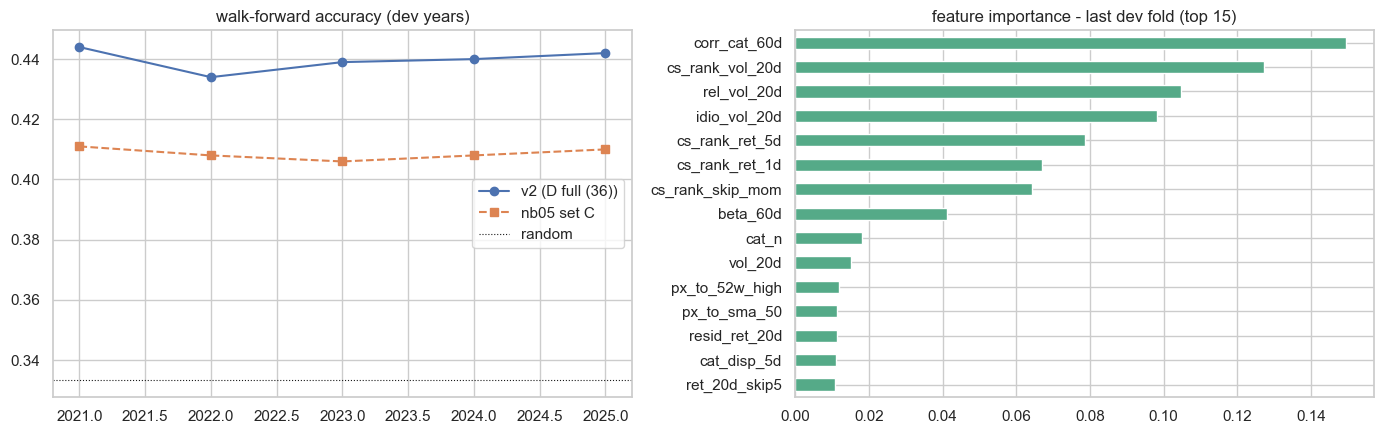

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
ax[0].plot(wf['test_year'], wf['accuracy'], marker='o', label=f'v2 ({best_name})')
ax[0].plot(wf['test_year'], wf['ref05_acc'], marker='s', ls='--', label='nb05 set C')
ax[0].axhline(1/3, color='k', ls=':', lw=.8, label='random')
ax[0].set_title('walk-forward accuracy (dev years)'); ax[0].legend()
pd.Series(wf_mdl.feature_importances_, index=best_cols).sort_values().tail(15).plot.barh(ax=ax[1], color='#5a8')
ax[1].set_title('feature importance - last dev fold (top 15)')
plt.tight_layout(); plt.show()

In [13]:
if run_tuned:
    wf_t, _ = walk_forward(best_cols, overrides={'max_depth': 6, 'n_estimators': 400})
    print(wf_t.to_string(index=False))
    print(f"\ntuned dev mean: acc {wf_t['accuracy'].mean():.3f}  mf1 {wf_t['macro_F1'].mean():.3f}"
          f"  (standard: {wf['accuracy'].mean():.3f} / {wf['macro_F1'].mean():.3f})")
    use_tuned = wf_t['accuracy'].mean() > wf['accuracy'].mean()
else:
    wf_t, use_tuned = None, False
final_overrides = {'max_depth': 6, 'n_estimators': 400} if use_tuned else None
print('final config for the 2026 touch:', 'tuned (depth 6, 400 trees)' if use_tuned else 'nb05-standard (depth 4, 250 trees)')

final config for the 2026 touch: nb05-standard (depth 4, 250 trees)


## 3) the touch-once holdout — 2026, scored exactly once

everything above (feature groups, capacity) was chosen on dev data only. this cell is the first
and only time v2 touches 2026. whatever it says, we report it and do **not** iterate against it.

In [14]:
hold, _ = walk_forward(best_cols, overrides=final_overrides, years=[2026])
print(hold.to_string(index=False))
print(f"\n2026 holdout: acc {hold['accuracy'].iloc[0]:.3f}  mf1 {hold['macro_F1'].iloc[0]:.3f}   (nb05 set C ref: 0.419 / 0.411)")

 test_year  n_train  n_test  accuracy  macro_F1  acc_nonoverlap  mf1_nonoverlap  ref05_acc
      2026  3164790  163567     0.447     0.439           0.436           0.428      0.419

2026 holdout: acc 0.447  mf1 0.439   (nb05 set C ref: 0.419 / 0.411)


## harness checks — shuffled label + planted-leak canary  (same as nb05)

run on the 2021 fold (smallest) with the selected feature set. shuffling the label within each
date must kill all signal (~0.333); planting the forward return as a feature must blow past every
honest number (the label is peer-relative, so the raw forward return is a diluted proxy — the bar
is best-honest + 0.05, not an absolute level; see nb05).

In [15]:
audit_Y = 2021
te_audit = d[d['date'].dt.year == audit_Y]
cut = purge_cutoff(prices.index, te_audit['date'].min(), H)
tr_audit = d[d['date'] <= cut]

rng = np.random.default_rng(0)
tr_shuf = tr_audit.copy()
tr_shuf['label_shuf'] = tr_shuf.groupby('date')['label'].transform(lambda s: rng.permutation(s.values))
shuf_mdl = make_model().fit(tr_shuf[best_cols], tr_shuf['label_shuf'])
shuf_acc = accuracy_score(te_audit['label'], shuf_mdl.predict(te_audit[best_cols]))
print(f'shuffled-label test on {best_name}: accuracy {shuf_acc:.3f}  (expect 0.333 +/- 0.01)')
assert abs(shuf_acc - 1/3) < 0.01, f'shuffled-label accuracy {shuf_acc:.3f} is not random - wiring bug'
print('PASS: no signal survives label shuffling.')
del tr_shuf, shuf_mdl

shuffled-label test on D full (36): accuracy 0.336  (expect 0.333 +/- 0.01)
PASS: no signal survives label shuffling.


In [16]:
fwd_leak = fwd.stack().rename('fwd_ret_5d')
canary_cols = best_cols + ['fwd_ret_5d']
tr_leak = tr_audit.join(fwd_leak, on=['date', 'ticker'])
te_leak = te_audit.join(fwd_leak, on=['date', 'ticker'])
leak_mdl = make_model().fit(tr_leak[canary_cols], tr_leak['label'])
leak_acc = accuracy_score(te_leak['label'], leak_mdl.predict(te_leak[canary_cols]))
best_honest = max(abl['accuracy'].max(), probe_acc, wf['accuracy'].mean(),
                  wf_t['accuracy'].mean() if wf_t is not None else 0)
print(f'planted-leak canary: accuracy {leak_acc:.3f}  vs best honest {best_honest:.3f}')
assert leak_acc > best_honest + 0.05, f'canary {leak_acc:.3f} vs honest {best_honest:.3f} - harness failed to detect an obvious leak!'
print('PASS: harness correctly detects an injected leak.')
del fwd_leak, tr_leak, te_leak, leak_mdl

planted-leak canary: accuracy 0.578  vs best honest 0.443
PASS: harness correctly detects an injected leak.


## verdict

In [17]:
dev_acc, dev_mf1 = wf['accuracy'].mean(), wf['macro_F1'].mean()
cfg_used = 'nb05-standard (depth 4, 250 trees)'
if use_tuned:
    dev_acc, dev_mf1 = wf_t['accuracy'].mean(), wf_t['macro_F1'].mean()
    cfg_used = 'tuned (depth 6, 400 trees)'
h_acc, h_mf1 = hold['accuracy'].iloc[0], hold['macro_F1'].iloc[0]
all_acc = (dev_acc * 5 + h_acc) / 6
print('=' * 68)
print(f'nb05 set C, dev folds 2021-2025 : acc 0.409   mf1 0.393')
print(f'v2 {best_name:<21}   dev : acc {dev_acc:.3f}   mf1 {dev_mf1:.3f}   ({(dev_acc-0.409)*100:+.1f} acc pts)')
print(f'2026 touch-once holdout          : acc {h_acc:.3f}   mf1 {h_mf1:.3f}   (nb05 ref 0.419 / 0.411)')
print(f'all six folds, mean              : acc {all_acc:.3f}   (nb05: 0.410)')
print(f'model config                     : {cfg_used}')
print('=' * 68)
print('audits: truncation PASS | forward-corr small | shuffled-label PASS | canary PASS')
print('2026 has now been touched once by v2 - further feature iterations must treat it as spent,')
print('or wait for new out-of-sample data to accrue.')

nb05 set C, dev folds 2021-2025 : acc 0.409   mf1 0.393
v2 D full (36)             dev : acc 0.440   mf1 0.431   (+3.1 acc pts)
2026 touch-once holdout          : acc 0.447   mf1 0.439   (nb05 ref 0.419 / 0.411)
all six folds, mean              : acc 0.441   (nb05: 0.410)
model config                     : nb05-standard (depth 4, 250 trees)
audits: truncation PASS | forward-corr small | shuffled-label PASS | canary PASS
2026 has now been touched once by v2 - further feature iterations must treat it as spent,
or wait for new out-of-sample data to accrue.


In [18]:
df

NameError: name 'df' is not defined